In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Preparar datos
df = pd.read_csv('datasetAIQ.csv', sep=';')
df.head()

,no2,ozone,temperature,humidity,estimates
0,0.00,73,5.78,94.54,1
1,0.01,21,-8.55,17.75,0
2,0.01,8,-9.46,61.97,0
3,0.01,5,29.20,95.45,0
4,0.01,46,15.66,22.63,1


<Axes: xlabel='estimates', ylabel='count'>

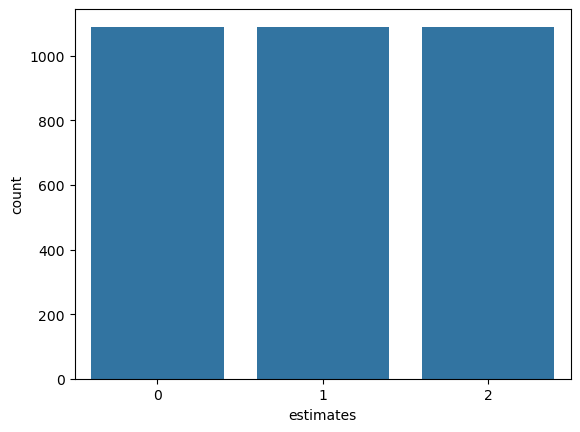

In [3]:
#Verificar si hay una proporción equilibrada entre los diferentes valores de la variable objetivo para un buen modelado posterior
sns.countplot(x='estimates',data=df)

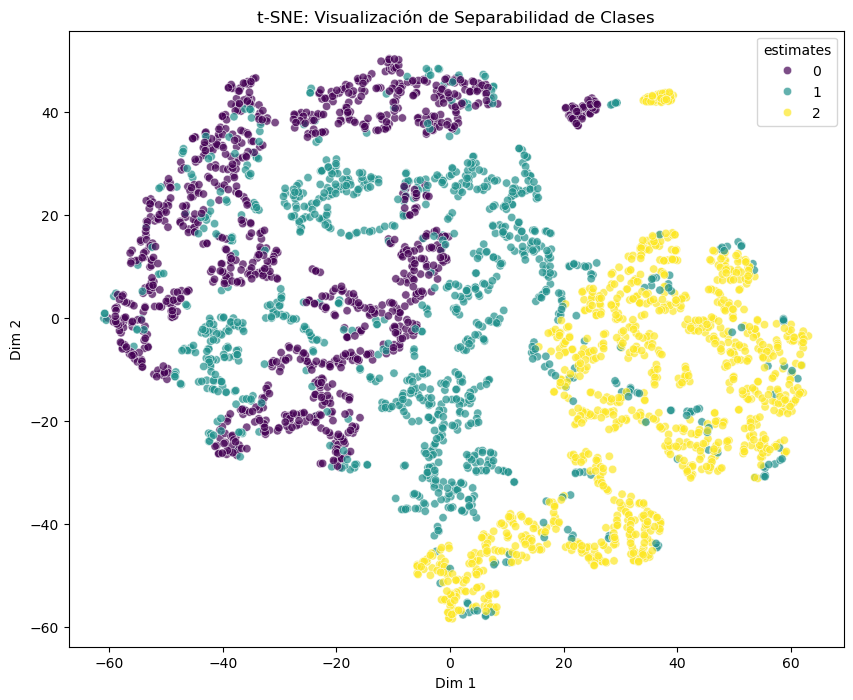

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Cargar datos
df = pd.read_csv('datasetAIQ.csv', sep=';')

# Separar features y target
X = df.drop('estimates', axis=1)
y = df['estimates']

# Escalar los datos (crucial para t-SNE)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Calcular t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

# Crear DataFrame para graficar
tsne_df = pd.DataFrame(data=X_tsne, columns=['Dim 1', 'Dim 2'])
tsne_df['estimates'] = y

# Graficar
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Dim 1', y='Dim 2', hue='estimates', data=tsne_df, palette='viridis', alpha=0.7)
plt.title('t-SNE: Visualización de Separabilidad de Clases')
plt.savefig('tsne_plot.png')